In [2]:
import os
import glob
import cv2
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore")
#from datasets import Dataset, load_dataset,load_from_disk

In [40]:
'''
dataset_path = "./dataset"
dataframe_pkl_path = os.path.join(dataset_path, "dataframe.pkl")

if not os.path.exists(dataframe_pkl_path):
    print("dataframe.pkl not found. Loading and saving dataset...")
    dataframe = load_dataset("OpenRL/DeepFakeFace")
    dataframe.save_to_disk(dataset_path)
    print("Dataset loaded and saved successfully.")
else:
    dataframe = load_from_disk("./dataset")
    print("Dataset loaded.")
'''

'\ndataset_path = "./dataset"\ndataframe_pkl_path = os.path.join(dataset_path, "dataframe.pkl")\n\nif not os.path.exists(dataframe_pkl_path):\n    print("dataframe.pkl not found. Loading and saving dataset...")\n    dataframe = load_dataset("OpenRL/DeepFakeFace")\n    dataframe.save_to_disk(dataset_path)\n    print("Dataset loaded and saved successfully.")\nelse:\n    dataframe = load_from_disk("./dataset")\n    print("Dataset loaded.")\n'

In [5]:
def create_dataset(path,type):
    dataset = {"image_path":[],"img_status":[],"from":[],"split":""}
    for where in os.listdir(path):
        with tqdm(total=100, desc=f"Load from {where}") as pbar:
            for folder in os.listdir(path+"/"+where):
                for image in glob.glob(path+where+"/"+folder+"/"+"*.jpg"):
                    dataset["image_path"].append(image)
                    dataset["img_status"].append(type)
                    dataset["from"].append(where)
                pbar.update(1)
    return dataset

dataset_real = pd.DataFrame(create_dataset('./dataset/real/','1'))
dataset_fake = pd.DataFrame(create_dataset('./dataset/fake/','0'))
df = pd.concat([dataset_real, dataset_fake], ignore_index=True)

Load from text2img: 100%|██████████| 100/100 [00:00<00:00, 304.53it/s]


In [4]:
print(df.shape)

(120000, 4)


The dataset contains 120 000 images and 2 features (image_path and img_status) the img_status correspond to 1 = true and 0 = fake

We can see all the images using the code below and slide the bar to the number we want

In [6]:
title_window = 'deep Fake Images'
alpha_slider_max = 119999

def on_trackbar(val):
    img = cv2.imread(df['image_path'][val])
    cv2.imshow(title_window, img)

cv2.namedWindow(title_window)

trackbar_name = 'Photo Index'
cv2.createTrackbar(trackbar_name, title_window , 0, alpha_slider_max, on_trackbar)

img = cv2.imread(df['image_path'][0])


cv2.imshow(title_window, img)
cv2.waitKey(0)
cv2.destroyAllWindows()

As we can see, the Distribution is extremely unbalanced.

Real: 30000
Fake: 90000



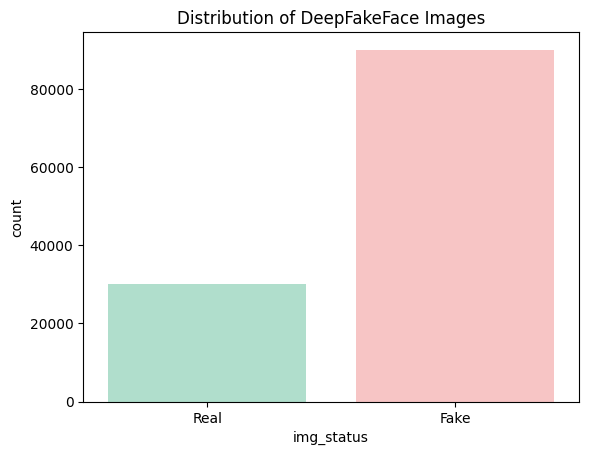

In [91]:
real = df.value_counts("img_status")[1]
fake = df.value_counts("img_status")[0]

print(f"Real: {real}\nFake: {fake}\n")
sns.countplot(x=df["img_status"],palette=["#A8E6CE", "#FFBDBD"])
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title("Distribution of DeepFakeFace Images")
plt.show()

In [92]:
from sklearn.model_selection import train_test_split

X = df.drop('img_status', axis=1)  # Features
y = df['img_status'] 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train['label'] = y_train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
X_val['label'] = y_val
X_test['label'] = y_test


In [109]:
import shutil

with tqdm(total=100, desc=f"Copy to Train") as pbar:
    i=0
    for index, row in X_train.iterrows():
        filename, file_extension = os.path.splitext(os.path.basename(X_train['image_path'][index]))
        new_filename = filename +'_'+ X_train['from'][index] + file_extension
        if X_train['label'][index] == '1':
            destination_file_path = os.path.join('./dataset/train/real', new_filename)
            shutil.copy2(X_train['image_path'][index], destination_file_path)
        else:
            destination_file_path = os.path.join('./dataset/train/fake', new_filename)
            shutil.copy2(X_train['image_path'][index], destination_file_path)
        i+=1
        if i % 900 == 0:
            pbar.update(1)

with tqdm(total=100, desc=f"Copy to Validation") as pbar:
    i=0
    for index, row in X_val.iterrows():
        filename, file_extension = os.path.splitext(os.path.basename(X_val['image_path'][index]))
        new_filename = filename +'_'+ X_val['from'][index] + file_extension
        if X_val['label'][index] == '1':
            destination_file_path = os.path.join('./dataset/valid/real', new_filename)
            shutil.copy2(X_val['image_path'][index], destination_file_path)
        else:
            destination_file_path = os.path.join('./dataset/valid/fake', new_filename)
            shutil.copy2(X_val['image_path'][index], destination_file_path)
        i+=1
        if i % 150 == 0:
                pbar.update(1)
with tqdm(total=100, desc=f"Copy to Test") as pbar:
    i=0
    for index, row in X_test.iterrows():
        filename, file_extension = os.path.splitext(os.path.basename(X_test['image_path'][index]))
        new_filename = filename +'_'+ X_test['from'][index] + file_extension
        if X_test['label'][index] == '1':
            destination_file_path = os.path.join('./dataset/test/real', new_filename)
            shutil.copy2(X_test['image_path'][index], destination_file_path)
        else:
            destination_file_path = os.path.join('./dataset/test/fake', new_filename)
            shutil.copy2(X_test['image_path'][index], destination_file_path)
        i+=1
        if i % 150 == 0:
                pbar.update(1)

Copy to Test: 100%|██████████| 100/100 [08:49<00:00,  5.30s/it]
